In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../Data Sets/ford.csv")

In [4]:
df.shape

(17966, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  str    
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  str    
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  str    
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 1.2 MB


In [6]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [7]:
df.isna().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [8]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


<Axes: xlabel='price', ylabel='Count'>

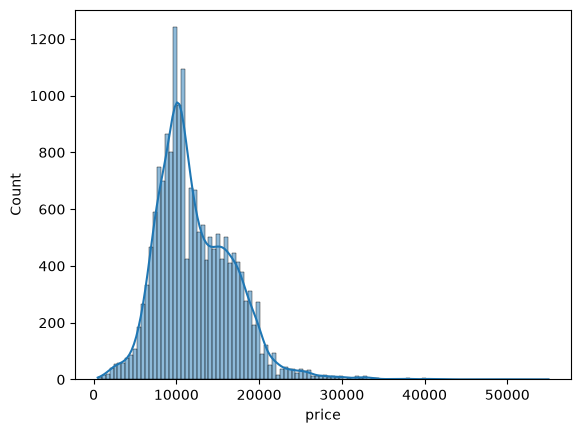

In [9]:
# Eda

sns.histplot(df['price'],kde=True)

In [10]:
df.corr(numeric_only=True)

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.636009,-0.707818,0.298506,-0.022967,-0.137311
price,0.636009,1.000000,-0.530659,0.406857,-0.346419,0.411178
mileage,-0.707818,-0.530659,1.000000,-0.260451,0.120075,0.215035
tax,0.298506,0.406857,-0.260451,1.000000,-0.502980,0.184363
mpg,-0.022967,-0.346419,0.120075,-0.502980,1.000000,-0.260521
engineSize,-0.137311,0.411178,0.215035,0.184363,-0.260521,1.000000


<Axes: >

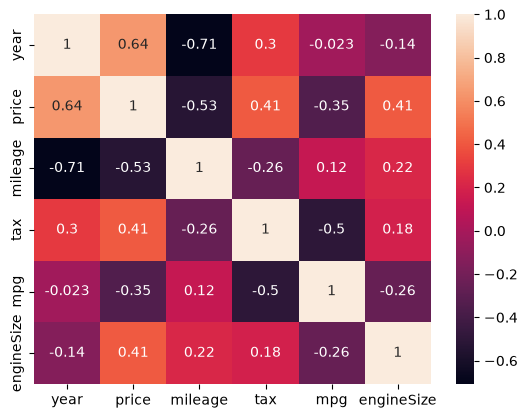

In [11]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [12]:
# sns.boxplot(data=df,x='price' ,y= 'engineSize')

<Axes: xlabel='year', ylabel='price'>

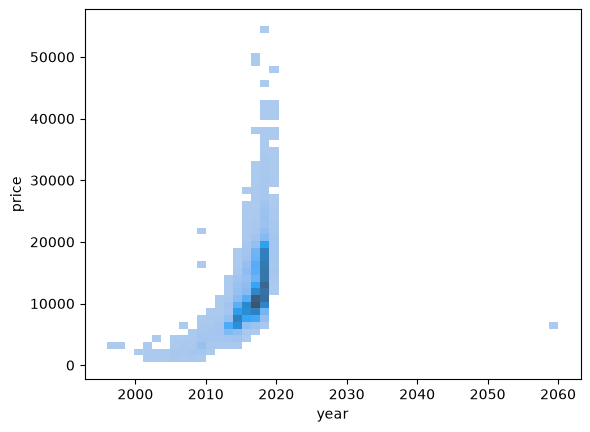

In [13]:
sns.histplot(data=df, y='price',x='year',bins=50)

In [19]:
df.head(1)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0


<Axes: xlabel='engineSize', ylabel='price'>

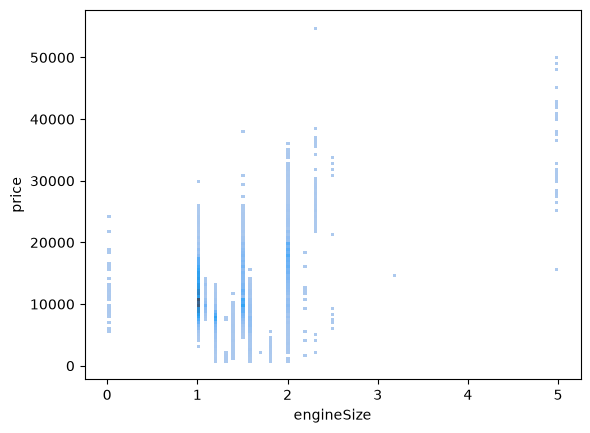

In [24]:
sns.histplot(data=df , x='engineSize',y='price')


In [31]:
X = df.drop(columns='price')
y=df['price']
X.head(1)

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0


In [33]:
# ONe hot encoding
X_new = pd.get_dummies(data=X ,columns=['transmission',"fuelType","model"],drop_first=True)

In [36]:
X_new.replace({True:1,False:0},inplace=True)

,year,mileage,tax,mpg,engineSize,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,...,model_ Mondeo,model_ Mustang,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus
0,2017,15944,150,57.7,1.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2018,9083,150,57.7,1.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2017,12456,150,57.7,1.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2019,10460,145,40.3,1.5,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2019,1482,145,48.7,1.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47.1,1.4,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17962,2014,40700,30,57.7,1.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17963,2015,7010,20,67.3,1.6,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17964,2018,5007,145,57.7,1.2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
# Lable Encoding
from sklearn.preprocessing import LabelEncoder

X_Lable = X
for i in ['model',"fuelType","transmission"]:
    enc=LabelEncoder()
    X_Lable[i] = enc.fit_transform(X_Lable[i].astype(str))

In [50]:
X_Lable.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,19,2017,0,15944,4,150,57.7,1.0
1,20,2018,1,9083,4,150,57.7,1.0
2,20,2017,1,12456,4,150,57.7,1.0
3,19,2019,1,10460,4,145,40.3,1.5
4,19,2019,0,1482,4,145,48.7,1.0


In [46]:
from sklearn.preprocessing import StandardScaler

cols = ["year", "mileage", "tax", "mpg", "engineSize"]
scalar = StandardScaler()
X_new[cols] = scalar.fit_transform(X_new[cols])
X_new.head()

,year,mileage,tax,mpg,engineSize,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,...,model_ Mondeo,model_ Mustang,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus
0,0.065128,-0.380998,0.591358,-0.020442,-0.811386,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.552866,-0.733359,0.591358,-0.020442,-0.811386,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.065128,-0.560132,0.591358,-0.020442,-0.811386,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1.040605,-0.662640,0.510727,-1.738890,0.345070,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1.040605,-1.123724,0.510727,-0.909294,-0.811386,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [53]:
X_Lable[
   [ "model", "year", "transmission", "mileage", "fuelType", "tax", "mpg", "engineSize"]
] = scalar.fit_transform(
    X_Lable[
        [
            "model",
            "year",
            "transmission",
            "mileage",
            "fuelType",
            "tax",
            "mpg",
            "engineSize",
        ]
    ]
)


In [54]:
X_Lable.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,0.603479,0.065128,-2.670032,-0.380998,0.688777,0.591358,-0.020442,-0.811386
1,0.750813,0.552866,0.041351,-0.733359,0.688777,0.591358,-0.020442,-0.811386
2,0.750813,0.065128,0.041351,-0.560132,0.688777,0.591358,-0.020442,-0.811386
3,0.603479,1.040605,0.041351,-0.662640,0.688777,0.510727,-1.738890,0.345070
4,0.603479,1.040605,-2.670032,-1.123724,0.688777,0.510727,-0.909294,-0.811386


In [77]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [85]:
model1 = LinearRegression()
model2 = LinearRegression()

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.33, random_state=42)
model1.fit(X_train , y_train)  

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](34,)","[ 2147.4 ,-1325.33, -62.78,..., 6724.23, 1716.56, -14.36]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](34,)","['year','mileage','tax',...,'model_ Tourneo Custom', 'model_ Transit Tourneo','model_Focus']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.062e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,34
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,31


In [87]:
model1_y_pred = model1.predict(X_test)
r2=r2_score(y_test,model1_y_pred)
n=X_test.shape[0]
p=X_test.shape[1]

adj_r2 = 1-((1-r2)*(n-1)) / (n-p-1)
r2 , adj_r2

(0.8402100144860558, 0.8392882534566235)

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X_Lable, y, test_size=0.33, random_state=42)
model2.fit(X_train , y_train)  

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 700.49, 2391.47, -94.44,..., 16.62,-1458.19, 1726.72]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['model','year','transmission',...,'tax','mpg','engineSize']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.228e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [89]:
model2_y_pred = model2.predict(X_test)

In [92]:
model2_y_pred = model2.predict(X_test)
r2=r2_score(y_test,model2_y_pred)
n=X_test.shape[0]
p=X_test.shape[1]

adj_r2 = 1-((1-r2)*(n-1)) / (n-p-1)
r2,adj_r2

(0.7459999306135431, 0.7456566872765344)